# Predicting Marathon Finish Times for Early Talent Identification in East African Athletics

## Mission & Problem
East Africa produces the world's best distance runners, yet talent identification remains informal and often happens too late in an athlete's development. This project builds a regression model that predicts a runner's marathon finish time from their profile and early-race split times, giving coaches and athletics federations a data-driven tool to spot promising endurance athletes earlier.

## Dataset
**Source:** Finishers Boston Marathon 2015–2017 (Kaggle, user *rojour*, scraped from official B.A.A. results).
**Size:** 79,638 finishers, 27 columns age, gender, country, checkpoint splits (5K–40K) and official finish time.
**Target variable:** `Official Time` (converted to minutes).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("data/boston_marathon_2015_2017.csv", low_memory=False)
print(f"Shape: {df.shape}")
df.head()

Shape: (79638, 27)


,Unnamed: 0,Bib,Name,Age,M/F,City,State,Country,Citizen,Unnamed: 9,...,35K,40K,Pace,Proj Time,Official Time,Overall,Gender,Division,Year,Unnamed: 8
0,0.0,3,"Desisa, Lelisa",25,M,Ambo,NaN,ETH,NaN,NaN,...,1:47:59,2:02:39,0:04:56,-,2:09:17,1,1,1,2015,NaN
1,1.0,4,"Tsegay, Yemane Adhane",30,M,Addis Ababa,NaN,ETH,NaN,NaN,...,1:47:59,2:02:42,0:04:58,-,2:09:48,2,2,2,2015,NaN
2,2.0,8,"Chebet, Wilson",29,M,Marakwet,NaN,KEN,NaN,NaN,...,1:47:59,2:03:01,0:04:59,-,2:10:22,3,3,3,2015,NaN
3,3.0,11,"Kipyego, Bernard",28,M,Eldoret,NaN,KEN,NaN,NaN,...,1:48:03,2:03:47,0:05:00,-,2:10:47,4,4,4,2015,NaN
4,4.0,10,"Korir, Wesley",32,M,Kitale,NaN,KEN,NaN,NaN,...,1:47:59,2:03:27,0:05:00,-,2:10:49,5,5,5,2015,NaN


## 1. Data Cleaning & Conversion to Numeric

Split times and the finish time are stored as `H:MM:SS` text strings, which a model cannot use directly, they must be converted to numeric values (total minutes). Gender (`M/F`) is categorical and is encoded as 1/0.

In [3]:
def time_to_minutes(t):
    """Convert an 'H:MM:SS' string to total minutes. Invalid values (e.g. '-') become NaN."""
    try:
        h, m, s = str(t).split(":")
        return int(h) * 60 + int(m) + int(s) / 60
    except (ValueError, AttributeError):
        return np.nan

time_cols = ["5K", "10K", "15K", "20K", "Half", "25K", "30K", "35K", "40K", "Official Time"]
for col in time_cols:
    new_name = "Finish_min" if col == "Official Time" else f"{col}_min"
    df[new_name] = df[col].apply(time_to_minutes)

# Encode gender: Male = 1, Female = 0
df["Gender_encoded"] = (df["M/F"] == "M").astype(int)

df[["Age", "M/F", "Gender_encoded", "5K_min", "Half_min", "Finish_min"]].head()

,Age,M/F,Gender_encoded,5K_min,Half_min,Finish_min
0,25,M,1,14.716667,64.033333,129.283333
1,30,M,1,14.716667,64.016667,129.800000
2,29,M,1,14.716667,64.033333,130.366667
3,28,M,1,14.716667,64.033333,130.783333
4,32,M,1,14.716667,64.016667,130.816667


## 2. Visualizations & Interpretation

### 2.1 Correlation Heatmap

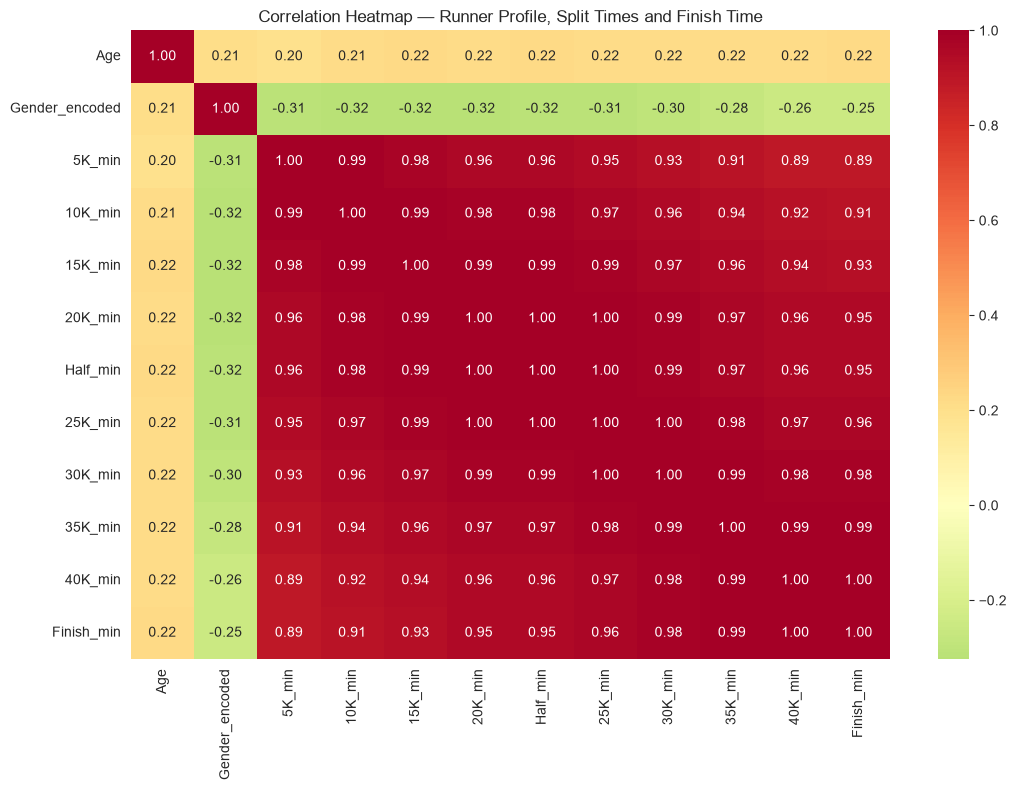

In [4]:
numeric_cols = ["Age", "Gender_encoded", "5K_min", "10K_min", "15K_min", "20K_min",
                "Half_min", "25K_min", "30K_min", "35K_min", "40K_min", "Finish_min"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0)
plt.title("Correlation Heatmap — Runner Profile, Split Times and Finish Time")
plt.tight_layout()
plt.show()

**Interpretation:**
- Split times are strongly positively correlated with the finish time, and the correlation grows the deeper into the race the split is taken (5K ≈ 0.89 → 40K ≈ 0.99). The pace→finish relationship is close to linear, confirming this problem suits linear regression.
- Age has a weak positive correlation with finish time and gender a moderate one — both are kept as features, but they carry far less weight than split times.
- Late splits (25K–40K) correlate almost perfectly (≥ 0.98) with the finish. Using them would make prediction trivial and defeat the mission: a coach needs a projection early in the race, not at kilometre 40. They will be dropped in feature engineering.

### 2.2 Distribution of the Target and Key Features